In [2]:
# Cell 1 — Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

np.random.seed(42)
print("Setup OK — xgboost", xgb.__version__)


Setup OK — xgboost 3.2.0


In [3]:
# Cell 2 — Load master dataset + regime labels, merge them

df = pd.read_pickle("../data/master_dataset.pkl")
regimes = pd.read_pickle("../data/processed/regime_labels.pkl")  # DataFrame with 'regime'

# Merge regime label onto the master (aligned by date)
df = df.join(regimes)   # adds the 'regime' column

print(f"Master shape       : {df.shape}")
print(f"Rows with regime   : {df['regime'].notna().sum()}")
print(f"Regime value counts:")
print(df["regime"].value_counts().sort_index().to_string())
print()
print(df[["DFL", "regime"]].head(3))

Master shape       : (3055, 44)
Rows with regime   : 3035
Regime value counts:
regime
0.000    1964
1.000     138
2.000      12
3.000     921

              DFL  regime
date                     
2014-01-02  0.240     NaN
2014-01-03 -0.285     NaN
2014-01-06 -0.160     NaN


In [4]:
# Cell 3 — Build target and feature matrix

# TARGET: next-day DFL change = the 1-day P&L of holding the DFL exposure.
# shift(-1) brings tomorrow's DFL onto today's row, so the model predicts the
# FUTURE move from features known TODAY (no look-ahead).
df["target"] = df["DFL"].shift(-1) - df["DFL"]      # = DFL(t+1) - DFL(t)

# FEATURES: everything known at the end of day t.
feature_cols = [
    "regime",
    # Curve structure
    "brent_l1_l2", "brent_l1_l3", "brent_l1_l6",
    "wti_l1_l2", "wti_l1_l3", "wti_l1_l6",
    "dubai_l1_l2", "dubai_l1_l3",
    # Cross-product spreads   
    "brent_wti_arb", "brent_dubai_efs", "gasoil_brent_crack",
    # Volatility
    "brent_l1_vol_20d", "dfl_vol_20d",
    # Macro
    "vix", "dxy", "vix_chg_5d", "dxy_chg_5d",
    # Fundamentals (XGBoost handles NaN natively → we can include them now)
    "crude_stock_anomaly", "dist_stock_anomaly",
    # DFL state (captures mean-reversion)
    "DFL",
]

# Build modeling dataset. Require target + regime to be present;
# the other features may contain NaN (XGBoost handles them natively).
model_df = df[feature_cols + ["target"]].copy()
model_df = model_df.dropna(subset=["target", "regime"])

print(f"Modeling dataset : {model_df.shape}")
print(f"Range            : {model_df.index.min().date()} → {model_df.index.max().date()}")
print(f"\nTarget (next-day ΔDFL) statistics:")
print(model_df["target"].describe().round(3).to_string())

Modeling dataset : (2994, 22)
Range            : 2014-01-30 → 2026-05-05

Target (next-day ΔDFL) statistics:
count   2994.000
mean      -0.001
std        1.174
min       -8.310
25%       -0.530
50%       -0.015
75%        0.514
max       18.410


In [5]:
# Cell 4 — Temporal train/test split (NEVER random for time series)

split_date = "2024-01-01"

train = model_df.loc[model_df.index < split_date]
test  = model_df.loc[model_df.index >= split_date]

X_train, y_train = train[feature_cols], train["target"]
X_test,  y_test  = test[feature_cols],  test["target"]

print(f"Train: {len(X_train)} days  ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test : {len(X_test)} days  ({test.index.min().date()} → {test.index.max().date()})")
print()
print("Regime share — train vs test:")
comp = pd.DataFrame({
    "train": train["regime"].value_counts(normalize=True).sort_index(),
    "test":  test["regime"].value_counts(normalize=True).sort_index(),
}).fillna(0).round(3)
print(comp.to_string())

Train: 2407 days  (2014-01-30 → 2023-12-29)
Test : 587 days  (2024-01-02 → 2026-05-05)

Regime share — train vs test:
        train  test
regime             
0.000   0.582 0.927
1.000   0.044 0.053
2.000   0.000 0.020
3.000   0.374 0.000


In [6]:
# Cell 5 — Fit XGBoost quantile regression for the VaR quantiles

quantiles = np.array([0.01, 0.05, 0.95, 0.99])

model = xgb.XGBRegressor(
    objective="reg:quantileerror",   # quantile (pinball) loss
    quantile_alpha=quantiles,         # fit all 4 quantiles jointly
    n_estimators=300,
    max_depth=3,                      # shallow → avoid overfitting on ~2400 samples
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
model.fit(X_train, y_train)

# Predict the quantiles
pred_test = model.predict(X_test)     # shape (n_test, 4)

q_names = [f"q{int(q*100):02d}" for q in quantiles]   # q01, q05, q95, q99
pred_test_df = pd.DataFrame(pred_test, index=X_test.index, columns=q_names)

print(f"Quantiles fitted : {list(quantiles)}")
print(f"Test predictions : {pred_test.shape}")
print()
print("Sample predicted quantiles of next-day ΔDFL (test set):")
print(pred_test_df.head(5).round(3).to_string())

# Check for quantile crossing (q01 ≤ q05 ≤ q95 ≤ q99 should hold)
crossing = ((pred_test_df["q01"] > pred_test_df["q05"]) |
            (pred_test_df["q05"] > pred_test_df["q95"]) |
            (pred_test_df["q95"] > pred_test_df["q99"])).sum()
print(f"\nQuantile-crossing rows: {crossing} (should be 0 or very few)")

Quantiles fitted : [np.float64(0.01), np.float64(0.05), np.float64(0.95), np.float64(0.99)]
Test predictions : (587, 4)

Sample predicted quantiles of next-day ΔDFL (test set):
              q01    q05   q95   q99
date                                
2024-01-02 -2.311 -1.584 1.063 2.165
2024-01-03 -1.699 -0.861 1.099 1.557
2024-01-04 -1.838 -0.937 1.488 1.677
2024-01-05 -1.770 -1.196 0.762 1.356
2024-01-08 -2.220 -1.295 1.099 1.911

Quantile-crossing rows: 19 (should be 0 or very few)


In [7]:
# Cell 5b — Diagnose where crossings occur, then fix via rearrangement

# Where do the crossings happen?
crossing_mask = ((pred_test_df["q01"] > pred_test_df["q05"]) |
                (pred_test_df["q05"] > pred_test_df["q95"]) |
                (pred_test_df["q95"] > pred_test_df["q99"]))
print(f"Crossing rows: {crossing_mask.sum()}")
print("Dates with crossings (first 20):")
for d in pred_test_df.loc[crossing_mask].index[:20]:
    print(f"  {d.date()}  (regime {int(test.loc[d, 'regime'])})")

# FIX: rearrange (sort) the quantiles per row.
# Chernozhukov, Fernández-Val & Galichon (2010): sorting quantile estimates is a
# valid monotonization that cannot increase estimation error. Standard practice.
pred_test_df = pd.DataFrame(
    np.sort(pred_test_df.values, axis=1),
    index=pred_test_df.index, columns=q_names,
)

# Re-check
crossing_after = ((pred_test_df["q01"] > pred_test_df["q05"]) |
                (pred_test_df["q05"] > pred_test_df["q95"]) |
                (pred_test_df["q95"] > pred_test_df["q99"])).sum()
print(f"\nCrossing rows after rearrangement: {crossing_after}")

Crossing rows: 19
Dates with crossings (first 20):
  2024-06-05  (regime 0)
  2025-04-23  (regime 0)
  2025-06-23  (regime 0)
  2026-01-30  (regime 0)
  2026-03-03  (regime 1)
  2026-03-19  (regime 2)
  2026-03-23  (regime 2)
  2026-03-24  (regime 2)
  2026-03-25  (regime 2)
  2026-03-26  (regime 1)
  2026-03-27  (regime 1)
  2026-03-30  (regime 1)
  2026-03-31  (regime 1)
  2026-04-01  (regime 1)
  2026-04-22  (regime 1)
  2026-04-24  (regime 1)
  2026-04-28  (regime 1)
  2026-04-29  (regime 1)
  2026-04-30  (regime 1)

Crossing rows after rearrangement: 0


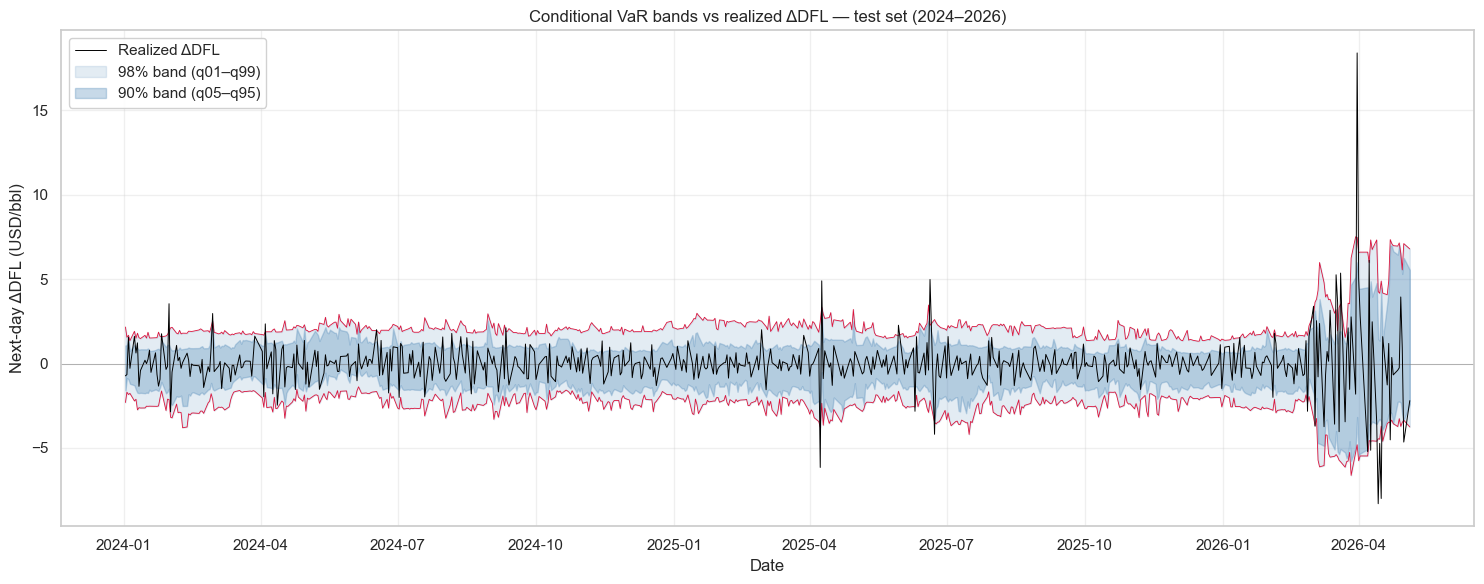

In [8]:
# Cell 6 — Visualize VaR bands vs realized ΔDFL on the test set

fig, ax = plt.subplots(figsize=(15, 6))

# Realized next-day ΔDFL
ax.plot(y_test.index, y_test.values, color="black", lw=0.7,
        label="Realized ΔDFL", zorder=3)

# VaR bands (filled)
ax.fill_between(pred_test_df.index, pred_test_df["q01"], pred_test_df["q99"],
                color="steelblue", alpha=0.15, label="98% band (q01–q99)")
ax.fill_between(pred_test_df.index, pred_test_df["q05"], pred_test_df["q95"],
                color="steelblue", alpha=0.30, label="90% band (q05–q95)")

# Extreme quantile lines
ax.plot(pred_test_df.index, pred_test_df["q99"], color="crimson", lw=0.6)
ax.plot(pred_test_df.index, pred_test_df["q01"], color="crimson", lw=0.6)

ax.axhline(0, color="gray", lw=0.4)
ax.set_ylabel("Next-day ΔDFL (USD/bbl)")
ax.set_xlabel("Date")
ax.set_title("Conditional VaR bands vs realized ΔDFL — test set (2024–2026)")
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Cell 7 — Exceedance (breach) rates: observed vs expected

print("=== VaR exceedance rates on the test set ===\n")
print(f"{'Quantile':<10}{'Side':<8}{'Expected':>10}{'Observed':>10}{'Breaches':>10}")
print("-" * 48)

checks = [
    ("q01", 0.01, "below"),
    ("q05", 0.05, "below"),
    ("q95", 0.95, "above"),
    ("q99", 0.99, "above"),   
]
n = len(y_test)
for qname, alpha, side in checks:
    if side == "below":
        breaches = int((y_test.values < pred_test_df[qname].values).sum())
        expected = alpha
    else:
        breaches = int((y_test.values > pred_test_df[qname].values).sum())
        expected = 1 - alpha
    obs_rate = breaches / n   
    print(f"{qname:<10}{side:<8}{expected:>10.1%}{obs_rate:>10.1%}{breaches:>10}")

=== VaR exceedance rates on the test set ===

Quantile  Side      Expected  Observed  Breaches
------------------------------------------------
q01       below         1.0%      1.9%        11
q05       below         5.0%      4.8%        28
q95       above         5.0%     10.7%        63
q99       above         1.0%      2.7%        16


In [10]:
# Cell 7b — Where do the upside breaches occur?

breach_q95 = y_test[y_test.values > pred_test_df["q95"].values]
print(f"q95 upside breaches: {len(breach_q95)}\n")
print("By year:")
print(breach_q95.index.year.value_counts().sort_index().to_string())
print("\nBy regime:")
print(test.loc[breach_q95.index, "regime"].value_counts().sort_index().to_string())

q95 upside breaches: 63

By year:
date
2024    31
2025    13
2026    19

By regime:
regime
0.000    53
1.000     5
2.000     5


In [11]:
# Cell 7c — Did the calm regime become more upside-volatile in test vs train?

for label, data in [("TRAIN", train), ("TEST", test)]:
    calm = data.loc[data["regime"] == 0, "target"].dropna()
    print(f"{label} calm ΔDFL: n={len(calm):>4}  mean={calm.mean():+.3f}  "
        f"std={calm.std():.3f}  q95={calm.quantile(0.95):+.3f}  q99={calm.quantile(0.99):+.3f}")

TRAIN calm ΔDFL: n=1400  mean=-0.006  std=0.993  q95=+1.561  q99=+2.795
TEST calm ΔDFL: n= 544  mean=+0.007  std=0.926  q95=+1.359  q99=+2.316


In [12]:
# Cell 7d — Is the model's predicted upper quantile too tight in calm?

calm_test = test[test["regime"] == 0].index
print("Calm regime, test set — empirical vs model-predicted:")
print(f"  Empirical q95 : {y_test.loc[calm_test].quantile(0.95):+.3f}")
print(f"  Model mean q95: {pred_test_df.loc[calm_test, 'q95'].mean():+.3f}")
print(f"  Empirical q99 : {y_test.loc[calm_test].quantile(0.99):+.3f}")
print(f"  Model mean q99: {pred_test_df.loc[calm_test, 'q99'].mean():+.3f}")

Calm regime, test set — empirical vs model-predicted:
  Empirical q95 : +1.359
  Model mean q95: +1.081
  Empirical q99 : +2.316
  Model mean q99: +2.000


In [13]:
# Cell 8 — Refit with SEPARATE models per quantile (isolate joint-vs-separate effect)

quantiles = [0.01, 0.05, 0.95, 0.99]
q_names = [f"q{int(q*100):02d}" for q in quantiles]

preds_sep = {}
for q, qn in zip(quantiles, q_names):
    m = xgb.XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q,             # a SINGLE quantile per model
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8, 
        random_state=42,
    )
    m.fit(X_train, y_train)
    preds_sep[qn] = m.predict(X_test)

# Rearrange to prevent crossing
pred_sep_df = pd.DataFrame(preds_sep, index=X_test.index)
pred_sep_df = pd.DataFrame(np.sort(pred_sep_df.values, axis=1),
                            index=pred_sep_df.index, columns=q_names)

# Re-check exceedance rates   
print("=== Exceedance rates: SEPARATE models ===\n")
print(f"{'Quantile':<10}{'Expected':>10}{'Observed':>10}")
print("-" * 30)
n = len(y_test)
for qn, q, side in [("q01",0.01,"below"),("q05",0.05,"below"),("q95",0.95,"above"),("q99",0.99,"above")]:
    if side == "below":
        br = int((y_test.values < pred_sep_df[qn].values).sum()); exp = q
    else:
        br = int((y_test.values > pred_sep_df[qn].values).sum()); exp = 1 - q
    print(f"{qn:<10}{exp:>10.1%}{br/n:>10.1%}")

# Compare model q95 vs empirical in calm
calm_test = test[test["regime"] == 0].index
print(f"\nCalm q95 — empirical {y_test.loc[calm_test].quantile(0.95):+.3f}  "
    f"vs separate-model {pred_sep_df.loc[calm_test,'q95'].mean():+.3f}")

=== Exceedance rates: SEPARATE models ===

Quantile    Expected  Observed
------------------------------
q01             1.0%      1.9%
q05             5.0%      4.4%
q95             5.0%     10.7%
q99             1.0%      3.1%

Calm q95 — empirical +1.359  vs separate-model +1.062


In [15]:
# Cell 8b — More capacity, checking train vs test

quantiles = [0.01, 0.05, 0.95, 0.99]
q_names = [f"q{int(q*100):02d}" for q in quantiles]

preds_tr, preds_te = {}, {}
for q, qn in zip(quantiles, q_names):
    m = xgb.XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=q,
        n_estimators=400,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    )
    m.fit(X_train, y_train)
    preds_tr[qn] = m.predict(X_train)
    preds_te[qn] = m.predict(X_test)

pred_tr_df = pd.DataFrame(np.sort(pd.DataFrame(preds_tr).values, axis=1),
                        index=X_train.index, columns=q_names)
pred_te_df = pd.DataFrame(np.sort(pd.DataFrame(preds_te).values, axis=1),
                        index=X_test.index, columns=q_names)

CHECKS = [
    ("q01", 0.01, "below"),
    ("q05", 0.05, "below"),
    ("q95", 0.95, "above"),
    ("q99", 0.99, "above"),
]

def coverage(y, pdf):
    out = {}
    for qn, q, side in CHECKS:
        if side == "below":
            out[qn] = (y.values < pdf[qn].values).mean()
        else:
            out[qn] = (y.values > pdf[qn].values).mean()
    return out

cov_tr = coverage(y_train, pred_tr_df)
cov_te = coverage(y_test, pred_te_df)

print(f"{'Quantile':<8}{'Expected':>10}{'Train':>10}{'Test':>10}")
print("-" * 38)
for qn, exp in [("q01", 0.01), ("q05", 0.05), ("q95", 0.05), ("q99", 0.01)]:
    print(f"{qn:<8}{exp:>10.1%}{cov_tr[qn]:>10.1%}{cov_te[qn]:>10.1%}")


Quantile  Expected     Train      Test
--------------------------------------
q01           1.0%      0.6%      2.4%
q05           5.0%      4.1%      5.8%
q95           5.0%      3.9%     13.1%
q99           1.0%      0.7%      3.2%


In [16]:
# Cell 9 — Conformal recalibration (split-conformal per quantile)

# 1. Split train temporally: proper-train (2014-2022) + calibration (2023)
calib_start = "2023-01-01"
proper_train = train.loc[train.index < calib_start]
calib        = train.loc[train.index >= calib_start]

Xpt, ypt = proper_train[feature_cols], proper_train["target"]
Xca, yca = calib[feature_cols], calib["target"]

# 2. Fit quantile models on proper-train (depth=3, the well-generalizing config)
quantiles = [0.01, 0.05, 0.95, 0.99]
q_names = [f"q{int(q*100):02d}" for q in quantiles]

models = {}
for q, qn in zip(quantiles, q_names):
    m = xgb.XGBRegressor(objective="reg:quantileerror", quantile_alpha=q,
                        n_estimators=300, max_depth=3, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8, random_state=42)
    m.fit(Xpt, ypt) 
    models[qn] = m

# 3. Conformal offset per quantile, computed on the calibration set.
#    Unified formula: offset = quantile_q( y_calib - pred_calib )
#    → after adding it, exactly q of calibration points fall on the right side.
offsets = {}
for q, qn in zip(quantiles, q_names):
    resid = yca.values - models[qn].predict(Xca)
    offsets[qn] = np.quantile(resid, q)

# 4. Apply offsets to test predictions, then rearrange
pred_cqr = {qn: models[qn].predict(X_test) + offsets[qn] for qn in q_names}
pred_cqr_df = pd.DataFrame(np.sort(pd.DataFrame(pred_cqr).values, axis=1),
                            index=X_test.index, columns=q_names)

# 5. Re-check coverage
print("Conformal offsets:", {k: round(v, 3) for k, v in offsets.items()})
print()
cov = coverage(y_test, pred_cqr_df)
print(f"{'Quantile':<8}{'Expected':>10}{'Test':>10}")
print("-" * 28)
for qn, exp in [("q01", 0.01), ("q05", 0.05), ("q95", 0.05), ("q99", 0.01)]:
    print(f"{qn:<8}{exp:>10.1%}{cov[qn]:>10.1%}")

Conformal offsets: {'q01': np.float64(0.25), 'q05': np.float64(0.15), 'q95': np.float64(0.463), 'q99': np.float64(0.707)}

Quantile  Expected      Test
----------------------------
q01           1.0%      1.9%
q05           5.0%      4.8%
q95           5.0%      6.5%
q99           1.0%      1.9%


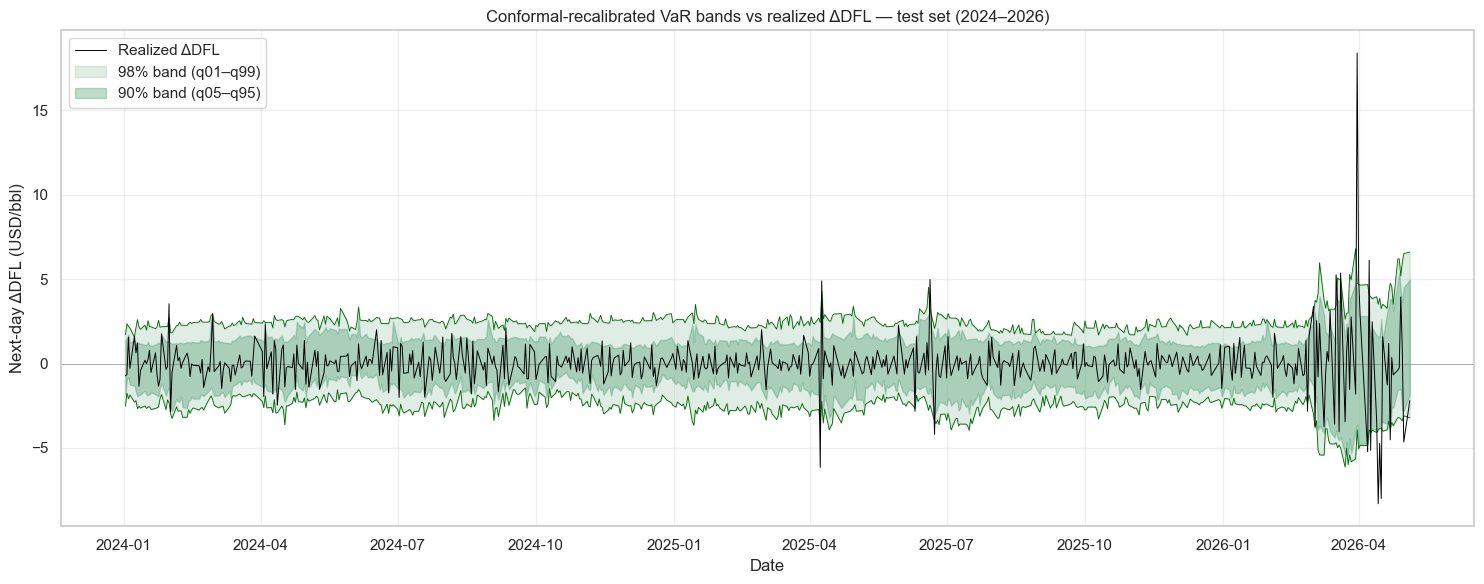

In [17]:
# Cell 10 — Recalibrated VaR bands vs realized ΔDFL

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(y_test.index, y_test.values, color="black", lw=0.7, label="Realized ΔDFL",
zorder=3)
ax.fill_between(pred_cqr_df.index, pred_cqr_df["q01"], pred_cqr_df["q99"],
                color="seagreen", alpha=0.15, label="98% band (q01–q99)")
ax.fill_between(pred_cqr_df.index, pred_cqr_df["q05"], pred_cqr_df["q95"],
                color="seagreen", alpha=0.30, label="90% band (q05–q95)")
ax.plot(pred_cqr_df.index, pred_cqr_df["q99"], color="darkgreen", lw=0.6)
ax.plot(pred_cqr_df.index, pred_cqr_df["q01"], color="darkgreen", lw=0.6)
ax.axhline(0, color="gray", lw=0.4)
ax.set_ylabel("Next-day ΔDFL (USD/bbl)")
ax.set_xlabel("Date")
ax.set_title("Conformal-recalibrated VaR bands vs realized ΔDFL — test set (2024–2026)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()  
plt.show()


In [18]:
# Cell 11 — Save recalibrated VaR predictions + realized values for the backtest

from pathlib import Path

backtest_df = pred_cqr_df.copy()
backtest_df["realized"] = y_test
backtest_df["regime"]   = test["regime"]

out_dir = Path("../data/processed")
backtest_df.to_pickle(out_dir / "var_predictions.pkl")
backtest_df.to_csv(out_dir / "var_predictions.csv")

print(f"Saved: {backtest_df.shape}  → {out_dir}/var_predictions.pkl + .csv")
print()
print(backtest_df.head().round(3).to_string())

Saved: (587, 6)  → ../data/processed/var_predictions.pkl + .csv

              q01    q05   q95   q99  realized  regime
date                                                  
2024-01-02 -2.528 -1.853 1.404 1.700    -0.730   0.000
2024-01-03 -1.756 -0.905 1.499 2.362    -0.655   0.000
2024-01-04 -2.082 -0.810 1.722 2.203     1.565   0.000
2024-01-05 -1.866 -1.256 1.243 2.109    -0.285   0.000
2024-01-08 -2.294 -1.311 1.397 1.556     1.610   0.000


## Conclusion — Conditional VaR with XGBoost quantile regression

### What we built

We modelled the **next-day change of the DFL** (the 1-day P&L of holding the basis)
and predicted its conditional quantiles (q01, q05, q95, q99) with **XGBoost quantile
regression**, using the regime label (notebook 03) plus continuous market-state
features (curve spreads, realized volatility, macro, stock anomalies). The split was
**temporal** (train 2014–2023, test 2024–2026), so the 2026 crisis is a genuine
out-of-sample stress event.

### The model adapts to the market

The predicted VaR bands are **tight in calm periods** (±2 USD/bbl) and **widen
sharply during the 2026 crisis** (±5–8), driven by the regime and volatility
features. This is the core value over a static historical VaR: the risk estimate
breathes with market conditions.

### Calibration diagnosis — a rigorous process

Initial exceedance rates revealed an **asymmetric calibration flaw**: the downside
(q01, q05) was well calibrated, but the upside was under-covered (q95 breached 10.7%
of the time vs 5% expected). We methodically ruled out three candidate causes:

1. **Distribution shift** — refuted: the calm regime in the test was actually
    slightly *less* volatile than in training.
2. **Joint vs separate quantile fitting** — refuted: fitting one model per quantile
    gave the same under-coverage.
3. **Under-regularization** — refuted: increasing capacity (deeper trees) improved
    *train* coverage but worsened *test* coverage (overfitting).

The conclusion: the upper quantile is **intrinsically hard to predict** from the
available features — the information simply isn't there, so no modelling choice fixes
it. The right tool is post-hoc recalibration.

### The fix — conformal recalibration

We applied **split-conformal quantile recalibration** (Romano et al. 2019): fit the
models on 2014–2022, compute a per-quantile offset on a 2023 calibration set, and add
it to the test predictions. The offsets were all positive and largest for the upper
quantiles (+0.46 for q95, +0.71 for q99), exactly correcting the under-prediction.

Post-recalibration coverage:

| Quantile | Expected | Before | After |
|---|---|---|---|
| q01 | 1.0% | 1.9% | 1.9% |
| q05 | 5.0% | 4.8% | 4.8% |
| q95 | 5.0% | 10.7% | 6.5% |
| q99 | 1.0% | 2.7% | 1.9% |

The residual small over-breaches reflect the approximate exchangeability of conformal
prediction under time-series dependence, plus the unprecedented April-2026 event.

### Output

The recalibrated VaR predictions and realized changes are saved to
`data/processed/var_predictions.pkl` for formal backtesting in notebook 05
(Kupiec, Christoffersen, pinball loss, and comparison against parametric and
per-regime baselines). 
